In [1]:
from pathlib import Path
import os

from matplotlib import gridspec
import seaborn as sns
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from torch.utils.data import DataLoader

import sys
sys.path.append('../../')
sys.path.append('../')

from src import mod_cog_tasks as mct
from src import mod_cog_data_utils as mcdu
from src import analysis_utils as au
from src import plot_utils as pu
from src.mod_cog_tasks import *
from src import eg_utils

def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
    
device = get_device()
print(device)

['/home/mila/c/cornforj/eg_rnns/mod_cog_vizualisation/arial.ttf']
/home/mila/c/cornforj/eg_rnns/mod_cog_vizualisation/arial.ttf
/home/mila/c/cornforj/eg_rnns/mod_cog_vizualisation/arial.ttf
cpu


In [2]:
import mod_cog_tasks_no_randomness as mctnr

# Notebook Description:
-----

- Save activity for all of the tasks for DSA and viz use.

In [3]:
# Enable auto-reloading of modules
%load_ext autoreload
%autoreload 2

# 1. Trained models 

In [ ]:
from save_utils import get_results_dict, load_model

#  Get all final experiments 
linclab_drive  = Path("/network/projects/_groups/linclab_users/eg/")
results_dir = linclab_drive/"modcog/exp8_final_combined"
results_dict = get_results_dict(results_dir)
print("Results loaded", results_dict.keys())

#  Just load lognormal experiments
gd_exps_dict = results_dict.gd_log_normal 
eg_exps_dict = results_dict.eg_log_normal

n_seeds = None # n experiments out of 5 total to run
gd_exp_list = [d for k,d in gd_exps_dict.items() if k.startswith("seed")]
eg_exp_list = [d for k,d in eg_exps_dict.items() if k.startswith("seed")]
all_exps_list = gd_exp_list[:n_seeds] + eg_exp_list[:n_seeds]

In [5]:
# load models to test on task
seed_idx = 0
eg_run = eg_exp_list[seed_idx]
gd_run = gd_exp_list[seed_idx]

eg_model = load_model(eg_run)
gd_model = load_model(gd_run)

device = eg_utils.get_device()
eg_model = eg_model.to(device)
gd_model = gd_model.to(device)

Setting split bias


/home/mila/c/cornforj/eg_rnns/mod_cog_vizualisation/../src/analysis_utils.py:151: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path, map_locati

# 2. Data objects

In [6]:
env_strs = mct.get_mod_cog_dataset_labels()
envs = mctnr.get_mod_cog_dataset_envs()

In [7]:
env_strs[:10]

['go',
 'rtgo',
 'dlygo',
 'anti',
 'rtanti',
 'dlyanti',
 'dlygointl',
 'dlygointr',
 'dlyantiintl',
 'dlyantiintr']

In [8]:
# generate data 
env = dlygo()
task_id = 2

batch_size = 50
inputs = []
targets = []
for i in range(batch_size):
    env.new_trial()
    inputs.append(env.ob[None, ...])
    targets.append(env.gt[None, ...])
    
inputs_batch = np.vstack(inputs)
targets_batch = np.vstack(targets)
inputs_batch.shape, targets_batch.shape

((50, 20, 33), (50, 20))

In [9]:
def plot_batch(inputs_batch, targets_batch, n_to_plot = 10, fontsize=8, noise_sigma = 0.1):
    fig = plt.figure(figsize=(7.5, 3), dpi=200)
    batch_size = inputs_batch.shape[0]
    print("batch_size", batch_size)
    if n_to_plot is None or n_to_plot > batch_size: n_to_plot = batch_size
    
        
    gs = gridspec.GridSpec(14, n_to_plot, figure=fig, 
                        left=0.05, right=0.95, top=0.95, bottom=0.05, 
                        wspace=0.1, hspace=0.1)

    for batch_idx in range(n_to_plot):
        ob = inputs_batch[batch_idx]
        if noise_sigma != 0.0:
            noise = np.random.normal(loc=0.0, scale=noise_sigma, size=ob.shape)
            ob = ob + noise
        
        gt = targets_batch[batch_idx]
        seq_len = ob.shape[0]

        ax1 = fig.add_subplot(gs[0, batch_idx])
        ax2 = fig.add_subplot(gs[1:5, batch_idx])
        ax3 = fig.add_subplot(gs[5:9, batch_idx])
        ax4 = fig.add_subplot(gs[10:,batch_idx])

        # Plot fixation
        ax1.plot(ob[:, 0], "k")
        ax1.set_xlim(0, seq_len-1)
        ax1.set_ylim(-noise_sigma*5, 1+noise_sigma*5)
        #ax1.set_title(task_names[env_idx], fontsize=fontsize)
            
        # Inputs rings 
        im1  = ax2.imshow(ob[:, 1:17].T, aspect="auto", cmap="Blues", vmin=0-noise_sigma*3, vmax=1+noise_sigma*3)
        im2 = ax3.imshow(ob[:, 17:34].T, aspect="auto", cmap="Blues", vmin=0-noise_sigma*3, vmax=1+noise_sigma*3)

        imy = ax4.imshow(np.eye(17)[1+gt].T, aspect="auto", cmap="Blues")
        
        if batch_idx == 0:
            ax1.get_xaxis().set_visible(False)
            ax1.spines['top'].set_visible(False)
            ax1.spines['right'].set_visible(False)
            #ax1.spines['left'].set_visible(False)
            ax1.spines['bottom'].set_visible(False)
            ax1.tick_params(axis='y', labelsize=8) 
            
            ax2.set_ylabel("Input ring 1", fontsize=8)
            ax2.set_yticks([]) 
            ax2.set_xticks([]) 
            ax2.spines['top'].set_visible(False)
            ax2.spines['right'].set_visible(False)
            ax2.spines['left'].set_visible(False)
            ax2.spines['bottom'].set_visible(False)
            
            ax3.set_ylabel("Input ring 2", fontsize=8)
            ax3.set_yticks([]) 
            ax3.set_xticks([]) 
            ax3.spines['top'].set_visible(False)
            ax3.spines['right'].set_visible(False)
            ax3.spines['left'].set_visible(False)
            ax3.spines['bottom'].set_visible(False)
            ax4.set_ylabel("Target output", fontsize=8)

        else:
            for ax in [ax1, ax2, ax3]:
                ax.set_axis_off()
            
        # ax4.set_ylim(-0.5, env.action_space.n)
        ax4.set_xlim(0,seq_len-1)
        ax4.set_yticklabels([])
        ax4.set_yticks([])
        ax4.set_xlabel("Timestep #", fontsize=8)
        x_limits = ax4.get_xlim()
        sns.despine(ax=ax4, left=True, right=True, top=True, bottom=False, offset=2)
        # Set x-axis ticks to be at the start and end of the x-axis limits
        ax4.set_xticks([x_limits[0], x_limits[1]])
        ax4.tick_params(axis='x', which='major', labelsize=fontsize)  # for major ticks

    return fig

batch_size 50


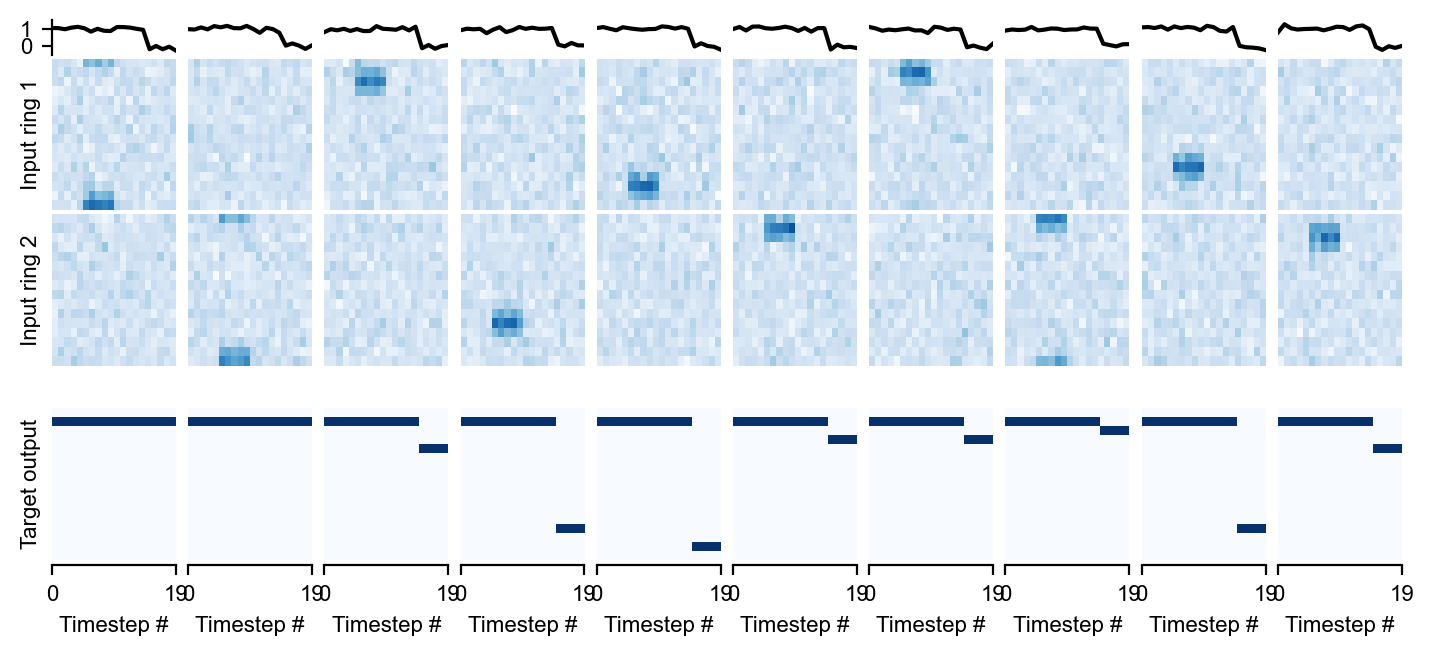

In [10]:
plot_batch(inputs_batch, targets_batch, n_to_plot=10, noise_sigma=0.1);

In [ ]:
# helpers for batch construction and accuracy
from save_utils import add_one_hot_encoding, compute_acc_with_fixation_unit

### Generate data in batches

For simplicity not considering more efficient alternatives

In [16]:
def construct_batch_list(env, task_id, batch_size, 
                         fix_delay=False, to_device=True):
    if fix_delay:
        print("Force delay to be non-random not implemented")
        raise NotImplementedError
        
    device = eg_utils.get_device()
    inputs = []
    targets = []
    timings = []
    for i in range(batch_size):
        env.new_trial()
        ob = env.ob[None, ...]        
        timings.append(env.end_ind.copy())
        label_input = np.ones(shape=[1, ob.shape[1], 1])*task_id
        ob = np.concatenate([ob, label_input], axis=-1)
        ob_onehot = add_one_hot_encoding(torch.from_numpy(ob.astype(np.float32)))

        if to_device: ob_onehot = ob_onehot.to(device)
        inputs.append(ob_onehot)
        targets.append(env.gt[None, ...]) 
    
    return inputs, targets, timings#, env

#dlygointl
dlygointl_idx = env_strs.index("go")
dlygointl = envs[dlygointl_idx]
inputs, targets, timings = construct_batch_list(dlygointl, dlygointl_idx, batch_size=3) #reduce for stack 50 


In [47]:
def lists_to_array(iterable):
    arr = np.empty(len(iterable), dtype=object)
    for i, x in enumerate(iterable):
        try:
            arr[i] = x.squeeze().cpu().numpy()
        except AttributeError:
            arr[i] = x.squeeze()
    return arr

In [51]:
def run_model_over_list(inputs, targets, model, add_noise):
    """
    Inputs and targets are a list of arrays
    """
    accs, dec_accs = [], []
    outputs, activations = [], []
    for idx, input_seq in enumerate(inputs):
        target_seq = targets[idx]
        if add_noise:
            noise = torch.normal(mean=0.0, std=0.1, size=input_seq.size(), device=device)
            output_seq, activation_seq = model(input_seq + noise , return_acts=True) 
        else:
            output_seq, activation_seq = model(input_seq, return_acts=True) 

        dec_mask = input_seq[:, :, 0] == 0
        acc, dec_acc = compute_acc_with_fixation_unit(output_seq, torch.from_numpy(target_seq).to(device), dec_mask)

        activations.append(activation_seq)
        outputs.append(output_seq)
        accs.append(acc)
        dec_accs.append(dec_acc)
    
    return outputs, activations, np.mean(accs), np.mean(dec_accs)
    
outputs, activations, acc, dec_acc = run_model_over_list(inputs, targets, eg_model.to(device), add_noise = True)
acc, dec_acc

(np.float64(0.9526627292999854), np.float64(0.8769230785278174))

In [52]:
acts_ = lists_to_array(activations)
targets_ = lists_to_array(targets)
timings_ = np.array(timings, dtype=object)

In [ ]:
np.savez("data.npz", acts=acts_, targets=targets_, timings=timings_)

In [54]:
data = np.load("data.npz", allow_pickle=True)

In [55]:
data["acts"].shape

(13,)

In [56]:
# update the loop code

def loop_over_tasks(model, batch_size=1, add_noise=True, verbose=True):
    env_strs = mct.get_mod_cog_dataset_labels()
    envs = mctnr.get_mod_cog_dataset_envs()
    
    for task_id, name in enumerate(env_strs[:]):
        env = envs[task_id]
        inputs, targets, timings = construct_batch_list(env, task_id, batch_size) 
        outputs, activations, acc, dec_acc = run_model_over_list(inputs, targets, model, add_noise = add_noise)
        
        # detect if batch is variable
        reference_timing = list(timings[0].values())
        s= ""
        if any(list(d.values()) != reference_timing for d in timings[1:]):
            s+="var batch"
        
        seq_lens = np.unique([a.shape[1] for a in inputs])
        
        if verbose:
            print(f"Acc {acc:.2f} Dec Acc {dec_acc:.2f}, {task_id}-{name}, {seq_lens}, {s}")

In [57]:
loop_over_tasks(eg_model,batch_size=10)

Acc 1.00 Dec Acc 1.00, 0-go, [15], 
Acc 1.00 Dec Acc 1.00, 1-rtgo, [10], 
Acc 1.00 Dec Acc 1.00, 2-dlygo, [20], 
Acc 1.00 Dec Acc 1.00, 3-anti, [15], 
Acc 0.99 Dec Acc 0.98, 4-rtanti, [10], 
Acc 1.00 Dec Acc 1.00, 5-dlyanti, [20], 
Acc 1.00 Dec Acc 1.00, 6-dlygointl, [21], 
Acc 1.00 Dec Acc 1.00, 7-dlygointr, [21], 
Acc 1.00 Dec Acc 1.00, 8-dlyantiintl, [21], 
Acc 1.00 Dec Acc 1.00, 9-dlyantiintr, [21], 
Acc 1.00 Dec Acc 1.00, 10-goseql, [20], 
Acc 1.00 Dec Acc 1.00, 11-goseqr, [20], 
Acc 1.00 Dec Acc 1.00, 12-dlygoseql, [25], 
Acc 1.00 Dec Acc 1.00, 13-dlygoseqr, [25], 
Acc 0.99 Dec Acc 0.98, 14-rtgoseqr, [10], 
Acc 0.99 Dec Acc 0.98, 15-rtgoseql, [10], 
Acc 1.00 Dec Acc 1.00, 16-antiseqr, [20], 
Acc 1.00 Dec Acc 1.00, 17-antiseql, [20], 
Acc 1.00 Dec Acc 1.00, 18-dlyantiseqr, [25], 
Acc 1.00 Dec Acc 1.00, 19-dlyantiseql, [25], 
Acc 0.99 Dec Acc 0.98, 20-rtantiseqr, [10], 
Acc 0.99 Dec Acc 0.98, 21-rtantiseql, [10], 
Acc 0.92 Dec Acc 0.80, 22-dm1, [13], 
Acc 1.00 Dec Acc 1.00, 23-dm2,

In [56]:
loop_over_tasks(gd_model,batch_size=10)

Acc 1.00 Dec Acc 1.00, 0-go, [15], 
Acc 1.00 Dec Acc 1.00, 1-rtgo, [10], 
Acc 1.00 Dec Acc 1.00, 2-dlygo, [20], 
Acc 1.00 Dec Acc 1.00, 3-anti, [15], 
Acc 1.00 Dec Acc 1.00, 4-rtanti, [10], 
Acc 1.00 Dec Acc 1.00, 5-dlyanti, [20], 
Acc 1.00 Dec Acc 1.00, 6-dlygointl, [15 18 19 21 22 25 26], var batch
Acc 1.00 Dec Acc 1.00, 7-dlygointr, [15 18 19 20 21 22 23 24 25], var batch
Acc 1.00 Dec Acc 1.00, 8-dlyantiintl, [20 21 22 24 25 26], var batch
Acc 1.00 Dec Acc 1.00, 9-dlyantiintr, [15 17 19 20 21 23 24 25 26], var batch
Acc 1.00 Dec Acc 1.00, 10-goseql, [20], 
Acc 1.00 Dec Acc 1.00, 11-goseqr, [20], 
Acc 1.00 Dec Acc 1.00, 12-dlygoseql, [25], 
Acc 1.00 Dec Acc 1.00, 13-dlygoseqr, [25], 
Acc 1.00 Dec Acc 1.00, 14-rtgoseqr, [10], 
Acc 1.00 Dec Acc 1.00, 15-rtgoseql, [10], 
Acc 1.00 Dec Acc 1.00, 16-antiseqr, [20], 
Acc 1.00 Dec Acc 1.00, 17-antiseql, [20], 
Acc 1.00 Dec Acc 1.00, 18-dlyantiseqr, [25], 
Acc 1.00 Dec Acc 1.00, 19-dlyantiseql, [25], 
Acc 1.00 Dec Acc 1.00, 20-rtantiseqr, [10

# Save activities for dsa analysis
----

And potentially fixed point finder. 

In [58]:
dsa_analysis_dir = linclab_drive/"modcog/analysis_dsa_fixlen/"
dsa_analysis_dir.mkdir(parents=True, exist_ok=True)
list(dsa_analysis_dir.iterdir())

[]

In [59]:
eg_dir = dsa_analysis_dir/"eg"
eg_dir.mkdir(parents=True, exist_ok=True)
list(eg_dir.iterdir())

[]

In [60]:
gd_dir = dsa_analysis_dir/"gd"
gd_dir.mkdir(parents=True, exist_ok=True)
list(gd_dir.iterdir())

[]

In [63]:
def save_exp_activations(exp_list, alg_analysis_dir, batch_size = 200, add_noise=True):
    """
    Saving logic is 
    #         if isinstance(activations, list):
    #             for i in range(batch_size):
    #                 acts[i] = activations[i].cpu().numpy()
    #         else: # tensor, we could save directly : acts = activations.cpu().numpy().astype(object)
    
    alg_save_dir = dsa_analysis_dir/"eg"/
    """
    env_strs = mct.get_mod_cog_dataset_labels()
    envs = mctnr.get_mod_cog_dataset_envs()
    
    dec_accs = []
    for run in exp_list:
        print("Seed:", run.cfg.seed)
        run_analysis_dir = alg_analysis_dir/("seed_"+str(run.cfg.seed))
        run_analysis_dir.mkdir(parents=True, exist_ok=True)
        model = load_model(run)
        device = eg_utils.get_device()
        model.to(device)

        for task_id, name in enumerate(env_strs[:]):
            env = envs[task_id]
            inputs, targets, timings = construct_batch_list(env, task_id, batch_size) 
            outputs, activations, acc, dec_acc = run_model_over_list(inputs, targets, model, add_noise = add_noise)
            
                
            acts_ = lists_to_array(activations)
            targets_ = lists_to_array(targets)
            timings_ = np.array(timings, dtype=object)

            savepath = run_analysis_dir/f"{task_id}_{name}_data.npz"
            np.savez(savepath, acts=acts_, targets=targets_, timings=timings_)
            
            #savepath = run_analysis_dir/f"{task_id}_{name}_acts.npy"
            #np.save(savepath, acts)
            print(dec_acc, acts_.shape, savepath)
            dec_accs.append(dec_acc)
    
    return np.mean(dec_accs)


In [64]:
save_exp_activations(eg_exp_list, eg_dir, batch_size = 200)

Seed: 5
Setting split bias
1.0 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa_fixlen/eg/seed_5/0_go_data.npz
0.9750000014901161 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa_fixlen/eg/seed_5/1_rtgo_data.npz
1.0 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa_fixlen/eg/seed_5/2_dlygo_data.npz
1.0 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa_fixlen/eg/seed_5/3_anti_data.npz
0.9720000016689301 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa_fixlen/eg/seed_5/4_rtanti_data.npz
1.0 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa_fixlen/eg/seed_5/5_dlyanti_data.npz
1.0 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa_fixlen/eg/seed_5/6_dlygointl_data.npz
1.0 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa_fixlen/eg/seed_5/7_dlygointr_data.npz
1.0 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa

np.float64(0.9748560979292704)

In [65]:
save_exp_activations(gd_exp_list, gd_dir, batch_size = 200)

Seed: 5
1.0 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa_fixlen/gd/seed_5/0_go_data.npz
0.9890000006556511 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa_fixlen/gd/seed_5/1_rtgo_data.npz
1.0 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa_fixlen/gd/seed_5/2_dlygo_data.npz
1.0 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa_fixlen/gd/seed_5/3_anti_data.npz
0.997000000178814 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa_fixlen/gd/seed_5/4_rtanti_data.npz
1.0 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa_fixlen/gd/seed_5/5_dlyanti_data.npz
1.0 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa_fixlen/gd/seed_5/6_dlygointl_data.npz
1.0 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa_fixlen/gd/seed_5/7_dlygointr_data.npz
1.0 (200,) /network/projects/_groups/linclab_users/eg/modcog/analysis_dsa_fixlen/gd/seed_5/8_

np.float64(0.9781426831196721)